# Part 1

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

In [3]:
df = pd.read_excel("YieldCurve.xlsx")
type(df)

pandas.core.frame.DataFrame

In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Maturity"] = pd.to_datetime(df["Maturity"], errors="coerce")

In [5]:
## Tenor calculation
def Tenor(start, maturity):
    num = (360 * (maturity.year - start.year)
           + 30 * (maturity.month - start.month)
           + (maturity.day - start.day))
    return num / 360

In [6]:
df["Tenor"] = df.apply(lambda row: Tenor(row["Date"], row["Maturity"]), axis=1)
df = df.dropna()

### NSS

In [56]:
## Nss spot rate curve equation
def nss_spot(t, beta0, beta1, beta2, beta3, tau1, tau2):
    t = np.asarray(t, dtype=float)
    def f(t, tau):
        x = t / tau
        # avoiding division by zero
        return (1 - np.exp(-x)) / np.where(x == 0, 1e-8, x)
    f1 = f(t, tau1)
    f2 = f(t, tau2)
    r = (beta0 + beta1 * f1 + beta2 * (f1 - np.exp(-t / tau1)) + beta3 * (f2 - np.exp(-t / tau2)))
    return r

In [9]:
## obejctive function for scipy optimize
def nss_objective(params, tenor, yield_):
    beta0, beta1, beta2, beta3, tau1, tau2 = params
    model = nss_spot(tenor, beta0, beta1, beta2, beta3, tau1, tau2)
    resid = model - yield_
    return np.sum(resid**2)

In [10]:
# Initial guess (Betas and Taus)
x0 = np.array([0.03, 0.01, -0.03, 0.05, 1.0, 20.0])

In [11]:
res = minimize(nss_objective, x0, args=(df["Tenor"], df["Yield"]), method="BFGS")
print("Success:", res.success)
print("Params:", res.x)
print("Current Function Value (SSR < 0.5):", res.fun)

Success: True
Params: [  4.5448396   -0.56727261 -10.38608098   7.64963292   1.87813532
   1.87812729]
Current Function Value (SSR < 0.5): 0.08506107324924647


In [12]:
## assigning param
beta0, beta1, beta2, beta3, tau1, tau2 = res.x

### Cubic Spline

In [14]:
df_sorted = df.sort_values("Tenor")
tenor_sorted = df_sorted["Tenor"].values
y_sorted_pct = df_sorted["Yield"].values

In [15]:
cs = CubicSpline(tenor_sorted, y_sorted_pct)

In [16]:
## Cross-checking the fit values
y3 = cs(3.0)
y7 = cs(7.0)
print("Spline 3Y:", float(y3))
print("Spline 7Y:", float(y7))

Spline 3Y: 3.4616716732870922
Spline 7Y: 3.7394917018454623


In [17]:
## Required values
y2 = cs(2.0)
y5 = cs(5.0)
y10 = cs(10.0)   # extrapolated slightly if last tenor < 10

print("Cubic Spline 2Y :", float(y2))
print("Cubic Spline 5Y :", float(y5))
print("Cubic Spline 10Y:", float(y10))

Cubic Spline 2Y : 3.458415069077149
Cubic Spline 5Y : 3.5747792822766384
Cubic Spline 10Y: 3.973185154641181


In [18]:
## Grid creation
t_grid = np.arange(1/6, 10 + 1/12, 1/12)  # monthly = 1/12

In [19]:
## NSS spot in %
spot_nss = nss_spot(t_grid, beta0, beta1, beta2, beta3, tau1, tau2)

In [20]:
## numeric instantaneous forward in %
def nss_forward_numeric(t_grid, h=1e-4):
    t_grid = np.asarray(t_grid)

    def B(u):
        return u * nss_spot(u, beta0, beta1, beta2, beta3, tau1, tau2)

    return (B(t_grid + h) - B(t_grid - h)) / (2 * h)

fwd_nss = nss_forward_numeric(t_grid)

In [21]:
## cubic spline in %
spline_curve = cs(t_grid)

## actual market points (0–10Y)
x_actual = tenor_sorted
y_actual = y_sorted_pct

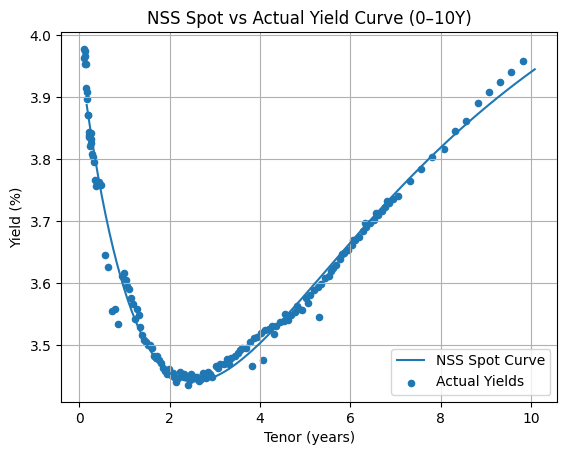

In [22]:
# 1) NSS spot vs actual
plt.figure()
plt.plot(t_grid, spot_nss, label="NSS Spot Curve")
plt.scatter(x_actual, y_actual, s=20, label="Actual Yields")
plt.xlabel("Tenor (years)")
plt.ylabel("Yield (%)")
plt.title("NSS Spot vs Actual Yield Curve (0–10Y)")
plt.legend()
plt.grid(True)

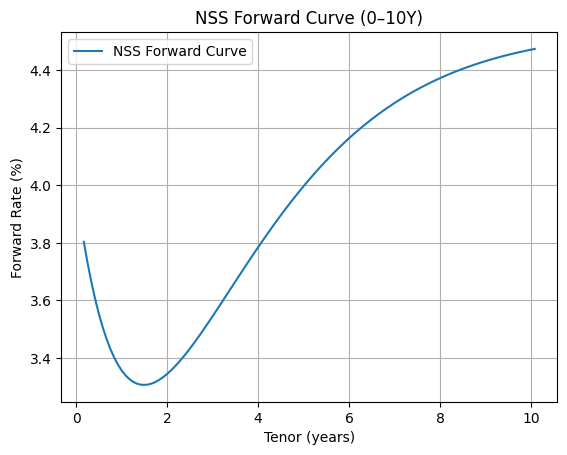

In [23]:
# 2) NSS forward
plt.figure()
plt.plot(t_grid, fwd_nss, label="NSS Forward Curve")
plt.xlabel("Tenor (years)")
plt.ylabel("Forward Rate (%)")
plt.title("NSS Forward Curve (0–10Y)")
plt.legend()
plt.grid(True)

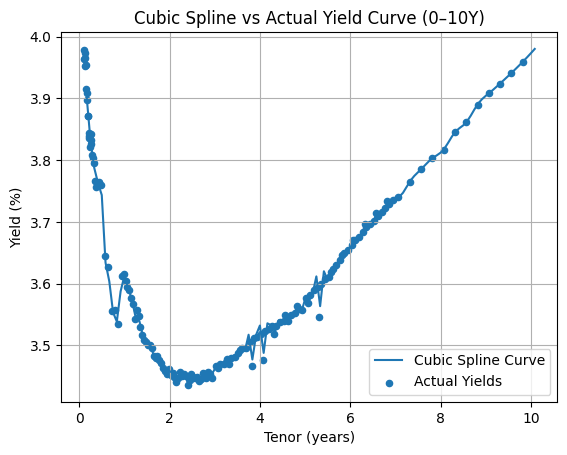

In [24]:
# 3) Cubic spline vs actual
plt.figure()
plt.plot(t_grid, spline_curve, label="Cubic Spline Curve")
plt.scatter(x_actual, y_actual, s=20, label="Actual Yields")
plt.xlabel("Tenor (years)")
plt.ylabel("Yield (%)")
plt.title("Cubic Spline vs Actual Yield Curve (0–10Y)")
plt.legend()
plt.grid(True)

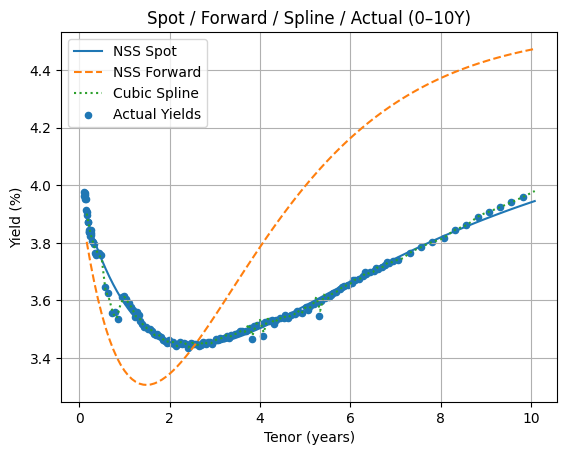

In [62]:
## combined
plt.figure()
plt.plot(t_grid, spot_nss, label="NSS Spot")
plt.plot(t_grid, fwd_nss, linestyle="--", label="NSS Forward")
plt.plot(t_grid, spline_curve, linestyle=":", label="Cubic Spline")
plt.scatter(x_actual, y_actual, s=20, label="Actual Yields")
plt.xlabel("Tenor (years)")
plt.ylabel("Yield (%)")
plt.title("Spot / Forward / Spline / Actual (0–10Y)")
plt.legend()
plt.grid(True)

# Part 2

In [78]:
## 2Y spot
r2  = nss_spot(2.0,  beta0, beta1, beta2, beta3, tau1, tau2)
## 5Y spot
r5  = nss_spot(5.0,  beta0, beta1, beta2, beta3, tau1, tau2)
## 10Y spot
r10 = nss_spot(10.0, beta0, beta1, beta2, beta3, tau1, tau2)
# 3M spot
r3m = nss_spot(0.25, beta0, beta1, beta2, beta3, tau1, tau2)

In [66]:
# 10yr rate – 2yr rate
_10y_2y = r10 - r2

# 5yr rate – 2yr rate
_5y_2y  = r5  - r2

# 10yr rate – 3-month rate
_10y_3m = r10 - r3m

In [74]:
print("The 10yr - 2yr spread =", _10y_2y)
print("The 5yr - 2yr spread =", _5y_2y)
print("The 10yr - 3m spread =", _10y_3m)

The 10yr - 2yr spread = 0.48522856972208306
The 5yr - 2yr spread = 0.12599266683327093
The 10yr - 3m spread = 0.09374245585164998


In [84]:
## 21m spot
r21m = nss_spot(1.75, beta0, beta1, beta2, beta3, tau1, tau2)
## 18m spot
r18m = nss_spot(1.5,  beta0, beta1, beta2, beta3, tau1, tau2)

In [88]:
## (1+s18​)*1.5 * (1+f3m18)*0.25=(1+s21​)*1.75
## f3m18 = 3-month forward rate in 18 months

s18 = r18m / 100.0
s21 = r21m / 100.0

num = (1 + s21)**1.75
den = (1 + s18)**1.5

f3m18 = (num / den)**4 - 1

In [90]:
print("3months forward rate in 18 months =", f3m18*100)

3months forward rate in 18 months = 3.3103074079759542


In [94]:
## 3-month rate, 18 months from now – 3-month rate
print("Near term forward rate =", f3m18*100 - r3m)

Near term forward rate = -0.5366532208613171


In [96]:
r3  = nss_spot(3.0,  beta0, beta1, beta2, beta3, tau1, tau2)

In [110]:
## f3y2 = 3yr rate-2 yr forward

s3yr = r3/100.0
s5yr = r5/100.0

num = (1 + s5yr)**5
den = (1 + s3yr)**3

f3y2 = (num / den)**0.5 - 1

In [112]:
##  3yr rate, 2yrs forward – Fed SEP terminal rate

print("3yr rate, 2yrs forward - Fed SEP terminal rate = ",f3y2*100 - 3.0)

3yr rate, 2yrs forward - Fed SEP terminal rate =  0.7801635979588522


## Interpretation for recession signal

* If short term yield are higehr than long term yield, markets expect the Fed to cut rates → recession signal.

* If short term yield are lower than long term yield, markets expect tightening/growth → non-recessionary.

10y − 2y (~0.49%)

Slightly positive slope → 10yr > 2yr yield hence not strongly recessionary by this measure.

5y − 2y (~0.13%)

Very shallow but still positive → 5yr > 2yr yield near-flat but not inverted mid-curve.

10y − 3m (~0.09%)

Essentially flat but very slightly positive → still non recessionary signal although no clear inversion and indicating a very flat curve.

Near-term forward spread (3m fwd in 18m − current 3m ≈ −0.54%)

Negative, which means that future rates are expected to be lower than current hence expectation for rates cut which signals rising recession risk hence recessionary signal.

3y rate, 2y forward − Fed SEP (~+0.78%)

Market expects somewhat higher long-run short-term rates (~3.78%) than the Fed’s 3% “longer-run” estimate which doesn;t signify any recessionary signal.